In [1]:
import yaml
import numpy as np
import polars as pl
from tqdm import tqdm
import statsmodels.api as sm

from plotnine import *
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'

In [2]:
# Configuration and paths
mac = 20
pheno_list_type = None
# pheno_list_type = 'biochemistry'
# pheno_list_type = 'overall_phenotype'

new_anno_df_path = None

# Load phenotype configuration
pheno_config_path = "/home/dnanexus/ukbgym/phenotype_config.yaml"
with open(pheno_config_path) as f:
    pheno_config = yaml.safe_load(f)

if pheno_list_type is not None:
    pheno_list = pheno_config[pheno_list_type]

eur_samples_path = '/home/dnanexus/data_dir/unrelated_cauc_samples_3rd_degree.csv'

# Load annotation configuration
config_path = "/home/dnanexus/ukbgym/config_odds.yaml"
with open(config_path) as f:
    config = yaml.safe_load(f)

records = [
    {
        "category": category,
        "annotation": anno,
        "color": props["color"],
        "label": props["label"],
        "annotation_dir": props.get("direction", 1),
    }
    for category, annos in config["rare_variant_annotations"].items()
    for anno, props in annos.items()
]

# Create the DataFrame directly from the list of records
anno_config_df = pl.DataFrame(records).with_columns(
    pl.col("annotation_dir").cast(pl.Int8)
)

all_annotation_list = anno_config_df.select(pl.col("annotation")).to_series().to_list()

anno_config_df

category,annotation,color,label,annotation_dir
str,str,str,str,i8
"""missense""","""am_pathogenicity""","""#FFCA28""","""AlphaMissense""",1
"""missense""","""esmscoremissense""","""#FB8C00""","""ESM1v""",-1
"""missense""","""score_pai3d""","""#D84315""","""PrimateAI-3D""",1
"""genetic_diversity""","""cadd_raw""","""#1f77b4""","""CADD Raw""",1
"""conservation""","""gpn_score""","""pink""","""GPN-MSA""",-1
…,…,…,…,…
"""splicing""","""absplice_dna_max""","""#00838F""","""AbSplice (max)""",1
"""splicing""","""absplice2_max""","""#26C6DA""","""AbSplice2 (max)""",1
"""regulatory_nondir""","""promoterai_abs""","""#00A99D""","""PromoterAI abs""",-1


In [3]:
# new_anno_df_path = '/home/dnanexus/data_dir/flashzoi_proximal_variants_gencode40_avg_score.parquet'

# new_anno_df = (
#     pl.read_parquet(new_anno_df_path)
#     .with_columns(
#         fz_blood = (pl.col('RNA:blood_7531') + pl.col('RNA:blood_7532') + pl.col('RNA:blood_7533'))/3
#     )
#     .with_columns(
#         max_fz_blood = pl.col('fz_blood').abs()
#     )
#     .select(['id', 'region', 'fz_blood', 'max_fz_blood'])
#     .lazy()
# )

# new_anno_df.head().collect()

In [4]:
!dx download project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/wgs/qced_maf1e-3_loftee_olink_genes/qced_maf1e-3_loftee_olink_genes_EURunrelated/annotations_fillna_ukbgym.parquet -o /home/dnanexus/data_dir/annotations_fillna_ukbgym.parquet

# !dx download project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/wgs/qced_maf1e-3_loftee_olink_genes/qced_maf1e-3_loftee_olink_genes_EURunrelated/annotations_ukbgym.parquet -o /home/dnanexus/data_dir/annotations_ukbgym.parquet

Error: path "/home/dnanexus/data_dir/annotations_fillna_ukbgym.parquet"
already exists but -f/--overwrite was not set


In [5]:
anno = pl.scan_parquet("/home/dnanexus/data_dir/annotations_fillna_ukbgym.parquet")

min_range = -500
max_range = +500

# Join new annotation if specified above
if new_anno_df_path is not None:
    anno = (
        anno
        .join(
            new_anno_df,
            on=['id', 'region'],
            how='left'
        )
    )

existing_annos = [c for c in all_annotation_list if c in anno.collect_schema().names()]
fillna_cols = [c+'_is_na' for c in existing_annos]

anno = (
    anno
    # .with_columns(
    #     encode_eh_pr = pl.any_horizontal((pl.col(c) == 1) for c in ['encode_pls', 'encode_pels', 'encode_dels']),
    #     encode_all_tf = pl.any_horizontal((pl.col(c) == 1) for c in ['encode_tf', 'encode_ca_tf']),
    # )
    .filter(
        # Choose CDS
        # (pl.col('vep_cds_relaxed')==True) &
        # ((pl.col('vep_cds_relaxed')==True) | (pl.col('mane_cds')==True)) &
        # (pl.col('non_mane_cds')==False) &

        # Choose non CDS only
        # ((pl.col('vep_cds_relaxed')==False) & (pl.col('mane_cds')==False) & (pl.col('non_mane_cds')==False)) &

        # Choose VEP consequence
        # (pl.col('consequence_synonymous_variant') == True) &
        (pl.col('consequence_missense_variant') == True) &
        # (pl.col('consequence_upstream_gene_variant') == True) &
        # (pl.col('consequence_downstream_gene_variant') == True) &
        # (pl.col('consequence_intron_variant') == True) &

        # Choose pLoF variants
        # (pl.col('loftee_hc') == True) &

        # Choose protein domain
        # (pl.col('ted_domain') == True) &
        # (pl.col('mobi_curated_disorder_priority') == True) &
        # (pl.col('mobi_lip_full') == True) &
        # (pl.col('low_complexity_domain') == True) &

        # Choose regulatory region
        # (pl.col('not_in_encode') == False) &
        # (pl.col('encode_eh_pr') == True) &
        # (pl.col('encode_all_tf') == True) &

        # Choose Gene Body
        # ((pl.col('consequence_upstream_gene_variant') == False) & (pl.col('consequence_downstream_gene_variant') == False)) &

        # Distance to TSS range
        # (pl.col('dist_to_tss') >= min_range) &
        # (pl.col('dist_to_tss') <= max_range) &

        # Only SNPs
        (pl.col('ref').str.len_chars()==1) & (pl.col('alt').str.len_chars()==1)
    )
    .select(
        set(['id', 'region', 'tss', 'strand', 'gene_length', 'gene_name', 'dist_to_tss']).union(set(existing_annos))
    )
    .collect(engine='streaming')
)

anno

esmscoremissense,cadd_raw,tss,gene_name,pangolin_score,gpn_score,delta_score,id,verphylop,abexp_abs_max,strand,absplice2_max,am_pathogenicity,region,promoterai,dist_to_tss,score_pai3d,gene_length,absplice_dna_max
f32,f32,i64,str,f32,f32,f32,str,f32,f32,cat,f32,f32,str,f32,i64,f32,i64,f32
-4.246,3.681756,87267882,"""RASA1""",0.03,-11.54,0.05,"""chr5:87376465:A:T""",8.687,0.060269,"""+""",0.000327,0.2063,"""ENSG00000145715""",0.0,108583,0.699444,124050,0.003
-6.253,3.032575,178830802,"""TTN""",0.03,-8.09,0.08,"""chr2:178598858:G:A""",6.948,0.015385,"""-""",0.000034,0.0,"""ENSG00000155657""",0.0,231944,0.0,304815,0.0
-5.721,4.428444,128318868,"""HS6ST1""",0.0,-5.12,0.0,"""chr2:128318064:C:T""",-0.102,0.160049,"""-""",0.000321,0.2002,"""ENSG00000136720""",0.0,804,0.550982,82154,0.003
-2.96,3.82475,10289951,"""ICAM5""",0.05,-7.08,0.02,"""chr19:10291335:A:G""",2.085,0.092082,"""+""",0.002196,0.4406,"""ENSG00000105376""",-0.0362,1384,0.500032,6828,0.002861
-5.738,1.767263,36127808,"""MAPK13""",0.0,-4.2,0.0,"""chr6:36138895:G:C""",1.412,0.073926,"""+""",0.000321,0.2106,"""ENSG00000156711""",0.0,11087,0.413456,16717,0.003
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
-10.954,5.023405,57447420,"""CIAPIN1""",0.05,-8.49,0.0,"""chr16:57439221:C:T""",6.853,0.128536,"""-""",0.005911,0.8515,"""ENSG00000005194""",0.0,8199,0.859038,19235,0.007
-4.81,2.443912,89701589,"""KIF20B""",0.0,-3.99,0.01,"""chr10:89725023:G:T""",0.449,0.111767,"""+""",0.000244,0.1879,"""ENSG00000138182""",0.0,23434,0.0,73351,0.003
-2.135,1.133668,55039446,"""PCSK9""",0.03,-0.27,0.08,"""chr1:55046566:C:T""",0.157,0.037832,"""+""",0.000206,0.0832,"""ENSG00000169174""",0.0,7120,0.328723,25407,0.004


In [6]:
anno_fillna = pl.scan_parquet("/home/dnanexus/data_dir/annotations_fillna_ukbgym.parquet")
fillna_cols = set([c+'_is_na' for c in existing_annos]).intersection(set(anno_fillna.collect_schema().names()))

anno_fillna_melted = (
    anno_fillna
    .select(['id', 'region'] + list(fillna_cols))
    .join(
        anno.select(['id', 'region']).lazy(), 
        on=['id', 'region'], 
        how='semi'
    )
    .unpivot(
        index=["id", "region"],
        on=list(fillna_cols),
        variable_name="annotation",
        value_name="annotation_is_na"
    )
    .filter(
        pl.col('annotation_is_na') == False
    )
    .with_columns(
        annotation = pl.col('annotation').str.replace('_is_na$', '')
    )
    # .collect(engine='streaming')
)

anno_fillna_melted.head().collect()

id,region,annotation,annotation_is_na
str,str,str,i8
"""chr5:87376465:A:T""","""ENSG00000145715""","""verphylop""",0
"""chr2:178598858:G:A""","""ENSG00000155657""","""verphylop""",0
"""chr2:128318064:C:T""","""ENSG00000136720""","""verphylop""",0
"""chr19:10291335:A:G""","""ENSG00000105376""","""verphylop""",0
"""chr6:36138895:G:C""","""ENSG00000156711""","""verphylop""",0


In [7]:
selected_annos = anno_config_df.filter(
    # (pl.col('category').is_in(['missense', 'genetic_diversity', 'conservation', 'splicing'])) # CDS
    pl.col('category').is_in(['missense', 'genetic_diversity', 'conservation']) # missense
    # pl.col('category').is_in(['genetic_diversity', 'conservation', 'splicing']) # 'splicing'

    # (pl.col('category').is_in(['genetic_diversity', 'splicing', 'conservation', 'regulatory_nondir'])) # non coding
    # (pl.col('category').is_in(['genetic_diversity', 'splicing', 'conservation'])) # introns
    # (pl.col('annotation').is_in(['am_pathogenicity', 'esmscoremissense', 'gpn_star_llr_calibrated_mean', 'cadd_raw', 'pangolin_score', 'abexp_abs_max']))
    # (pl.col('annotation').is_in(['am_pathogenicity', 'esmscoremissense', 'gpn_score', 'cadd_raw', 'pangolin_score', 'abexp_abs_max']))
)['annotation'].to_list()

melted_anno = (
    anno.lazy()

    .select(
        set(['id', 'region', 'gene_name']).union(set(selected_annos))
    )

    .unpivot(
        index=["id", "region", "gene_name"],
        on=selected_annos,
        variable_name="annotation",
        value_name="annotation_score"
    )
    .with_columns(
        pl.col("annotation_score").cast(pl.Float32),
        pl.col("region").cast(pl.Utf8),
    )

    # Merge with annotation configuration to get direction and filter
    .join(
        anno_config_df.select(["annotation", "category", "annotation_dir"]).lazy(),
        on="annotation",
        how="left"
    )

    # Remove null annotation scores
    .drop_nulls('annotation_score')

    # Correct scores by annotation direction
    .with_columns(
        annotation_score_dircor = pl.col('annotation_score') * pl.col("annotation_dir").cast(pl.Float32)
    )
    
    # Implement filtering based on the defined percentile
    .with_columns(
        annotation_score_dircor_rank_desc = pl.col('annotation_score_dircor').rank(method="max", descending=True).over(["annotation"]).cast(pl.Float32)
    )
    .drop(['annotation_score_dircor'])

    # Keep variants that don't have fillna annotation
    .join(
        anno_fillna_melted,
        on=['id', 'region', 'annotation'],
        how='semi'
    )

    .collect(engine='streaming')
)

melted_anno

id,region,gene_name,annotation,annotation_score,category,annotation_dir,annotation_score_dircor_rank_desc
str,str,str,str,f32,str,i8,f32
"""chr12:58888423:C:G""","""ENSG00000139263""","""LRIG3""","""gpn_score""",-11.91,"""conservation""",-1,17487.0
"""chr17:44374376:A:G""","""ENSG00000005961""","""ITGA2B""","""gpn_score""",-4.62,"""conservation""",-1,840270.0
"""chr11:118340581:T:C""","""ENSG00000167286""","""CD3D""","""gpn_score""",-1.46,"""conservation""",-1,1.119736e6
"""chr17:81685608:A:G""","""ENSG00000185359""","""HGS""","""gpn_score""",-9.03,"""conservation""",-1,240785.0
"""chr2:233772425:G:A""","""ENSG00000244122""","""UGT1A7""","""gpn_score""",-9.79,"""conservation""",-1,159216.0
…,…,…,…,…,…,…,…
"""chr2:96816533:T:C""","""ENSG00000168763""","""CNNM3""","""esmscoremissense""",-1.736,"""missense""",-1,1.196127e6
"""chr9:132336386:T:C""","""ENSG00000107290""","""SETX""","""esmscoremissense""",-3.444,"""missense""",-1,957621.0
"""chr7:151062007:G:A""","""ENSG00000164889""","""SLC4A2""","""esmscoremissense""",-4.881,"""missense""",-1,580272.0


In [8]:
anno['gene_name'].value_counts(sort=True)

gene_name,count
str,u64
"""TTN""",16636
"""MUC16""",8171
"""OBSCN""",5424
"""SYNE1""",4196
"""AHNAK2""",4035
…,…
"""APOC1""",21
"""TMSB10""",16
"""EIF5A""",16


In [9]:
!dx download project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/ukbgym/avg_pheno_per_var/loftee_mac20_quant_pheno_assocs_EURunrelated_appv_percentiles.parquet -o /home/dnanexus/data_dir/loftee_mac20_quant_pheno_assocs_EURunrelated_appv_percentiles.parquet

appv = pl.scan_parquet("/home/dnanexus/data_dir/loftee_mac20_quant_pheno_assocs_EURunrelated_appv_percentiles.parquet")

# Create a lazy frame with the unique keys
anno_keys = anno.select(pl.col('id').unique()).lazy()

# Chain the filter and the much faster semi join
appv = (
    appv
    .join(
        anno_keys, on='id', how='semi'
    )
    .filter(
        pl.col('n_individuals') <= mac
    )
    .select(
        ['id', 'phenotype', 'mean_pheno_value_ptile', 'n_individuals']
    )
)
# unique_phenotypes = appv.select('phenotype').unique().collect(engine='streaming').to_series()

Error: path "/home/dnanexus/data_dir/loftee_mac20_quant_pheno_assocs_EURunrela
ted_appv_percentiles.parquet" already exists but -f/--overwrite was not set


In [10]:
# Get gene trait associations
!dx download project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/REGENIE_results/regenie_127phenotypes_lofteeHC_mac20_EUR.parquet -o /home/dnanexus/data_dir/
# !dx download project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/REGENIE_results/loftee_mac20_associations_bh_corrected.parquet -o /home/dnanexus/data_dir/

!dx download project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/REGENIE_results/regenie_127phenotypes_mac20_lofteeHC_EUR_correlations.parquet -o /home/dnanexus/data_dir/

gene_trait_df = (
    pl.read_parquet('/home/dnanexus/data_dir/regenie_127phenotypes_lofteeHC_mac20_EUR.parquet')
    .filter(pl.col('pval_fdr')<=0.05)
    .select(['region', 'phenotype', 'pval_fdr'])
)

loftee_corrs = (
    pl.read_parquet('/home/dnanexus/data_dir/regenie_127phenotypes_mac20_lofteeHC_EUR_correlations.parquet')
    .with_columns(
        loftee_corr = pl.col('correlation'),
        loftee_corr_abs = pl.col('correlation').abs(),
        loftee_corr_dir = pl.col('correlation')/pl.col('correlation').abs(),
    )
    .select(['region', 'phenotype', 'loftee_corr', 'loftee_corr_abs', 'loftee_corr_dir']) 
)

gene_trait_df = (
    gene_trait_df
    .join(loftee_corrs, on=['region', 'phenotype'], how='inner')
    .drop_nans()
    # .sort('loftee_corr_abs', descending=True)
    # .sort('pval_fdr')
    # .unique(subset=["region"], keep="first", maintain_order=True)
)
gene_trait_df

Error: path
"/home/dnanexus/data_dir/regenie_127phenotypes_lofteeHC_mac20_EUR.parquet"
already exists but -f/--overwrite was not set
Error: path "/home/dnanexus/data_dir/regenie_127phenotypes_mac20_lofteeHC_EUR_
correlations.parquet" already exists but -f/--overwrite was not set


region,phenotype,pval_fdr,loftee_corr,loftee_corr_abs,loftee_corr_dir
str,str,f64,f64,f64,f64
"""ENSG00000067900""","""lymphocyte_count_int""",0.015659,-0.097882,0.097882,-1.0
"""ENSG00000145386""","""mean_corpuscular_haemoglobin_i…",0.000096,-0.059845,0.059845,-1.0
"""ENSG00000164944""","""trunk_predicted_mass_int""",0.015511,-0.04623,0.04623,-1.0
"""ENSG00000107863""","""trunk_predicted_mass_int""",0.033889,-0.122605,0.122605,-1.0
"""ENSG00000121966""","""eosinophill_percentage_int""",0.000392,-0.075765,0.075765,-1.0
…,…,…,…,…,…
"""ENSG00000142208""","""arm_predicted_mass_right_int""",0.009537,-0.049973,0.049973,-1.0
"""ENSG00000101670""","""cholesterol_int""",0.000099,0.035791,0.035791,1.0
"""ENSG00000017427""","""weight_int""",0.000158,-0.170599,0.170599,-1.0


In [11]:
# Get gene trait associations - OLD

# !dx download project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/association_files/rvat_EUR_500k_regenie.parquet -o /home/dnanexus/data_dir/association_files/rvat_EUR_500k_regenie.parquet
# plof = pl.read_parquet('/home/dnanexus/data_dir/association_files/rvat_EUR_500k_regenie.parquet').with_columns(
#     phenotype = (pl.col('trait') + '_int'),
#     region = pl.col('gene_id'),
#     rvat_pval = (10** -pl.col("neg_log10p")),
# ).filter(
#     (pl.col('trait_type') == 'quantitative')
# )

# !dx download project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/association_files/loftee_correlation_quantitative_wgs_EUR_genebass1e6_maf1e3_snp_consistent.parquet -o /home/dnanexus/data_dir/association_files/loftee_correlation_quantitative_wgs_EUR_genebass1e6_maf1e3_snp_consistent.parquet
# loftee_corr = pl.read_parquet("/home/dnanexus/data_dir/association_files/loftee_correlation_quantitative_wgs_EUR_genebass1e6_maf1e3_snp_consistent.parquet")

# gene_trait_df = loftee_corr.join(plof[['region', 'phenotype', 'beta', 'rvat_pval']], on=['region', 'phenotype'], how='inner').filter(
#     pl.col('loftee_corr')*pl.col('beta') > 0
# ).with_columns(
#     loftee_corr_dir = pl.col('loftee_corr')/pl.col('loftee_corr').abs()
# )

# if pheno_list_type is not None:
#     gene_trait_df = gene_trait_df.filter(pl.col('phenotype').is_in(pheno_list))

# gene_trait_df

## Odds ratio computation

In [12]:
n_steps = 101
min_rank_cutoff = 100
max_rank_cutoff = 10_000_000
max_rank_cutoff = np.min([max_rank_cutoff, anno.shape[0]])
or_threshold_pheno = 0.99

# We assume that all models score the same number of variants (all the variants in 'anno')
log_steps = np.geomspace(min_rank_cutoff, max_rank_cutoff, n_steps)

cutoffs_lazy = pl.LazyFrame({"rank_cutoff": log_steps.astype(int)})

cutoffs_lazy.collect()

rank_cutoff
i64
100
109
120
132
145
…
837240
919841
1010592


In [13]:
# --- 1. Lazily prepare the filter keys ---
region_keys = gene_trait_df.lazy().select(pl.col('region').unique())
anno_ids_lazy = melted_anno.lazy().join(
    region_keys, on='region', how='semi'
).select(pl.col('id').unique())


# --- Build main query (same as before, but stop before group_by) ---
gp_lazy = (
    appv
    .join(
        anno_ids_lazy, 
        on="id", 
        how="semi"
    )
    .join(
        melted_anno.lazy().drop([c for c in melted_anno.columns if 'is_nan' in c]), 
        on="id", 
        how="inner"
    )
    .join(
        gene_trait_df.lazy(), 
        on=["region", "phenotype"], 
        how="inner"
    )
    .with_columns(
        mean_pheno_value_dircor_ptile = pl.when(pl.col('loftee_corr_dir') == -1)
            .then(1 - pl.col('mean_pheno_value_ptile'))
            .otherwise(pl.col('mean_pheno_value_ptile')),
    )
)

# Cross join with cutoffs and compute odds ratios
or_lazy = (
    gp_lazy
    # .select(["annotation", "region", "gene_name", "phenotype", "n_vars_above_ptile", "mean_pheno_value_dircor_ptile"])
    .select(["annotation", "region", "gene_name", "phenotype", "annotation_score_dircor_rank_desc", "mean_pheno_value_dircor_ptile"])
    .join(cutoffs_lazy, how="cross")
    .group_by(["annotation", "region", "gene_name", "phenotype", "rank_cutoff"])
    .agg(
        n_dis_above_cutoff = (
            (pl.col("annotation_score_dircor_rank_desc") <= pl.col("rank_cutoff")) & 
            (pl.col("mean_pheno_value_dircor_ptile") >= or_threshold_pheno)
        ).sum(),
        n_notdis_above_cutoff = (
            (pl.col("annotation_score_dircor_rank_desc") <= pl.col("rank_cutoff")) &
            (pl.col("mean_pheno_value_dircor_ptile") < or_threshold_pheno)
        ).sum(),
        n_dis_below_cutoff = (
            (pl.col("annotation_score_dircor_rank_desc") > pl.col("rank_cutoff")) &
            (pl.col("mean_pheno_value_dircor_ptile") >= or_threshold_pheno)
        ).sum(),
        n_notdis_below_cutoff = (
            (pl.col("annotation_score_dircor_rank_desc") > pl.col("rank_cutoff")) &
            (pl.col("mean_pheno_value_dircor_ptile") < or_threshold_pheno)
        ).sum()
    )
    .with_columns(
        odds_ratio = (pl.col("n_dis_above_cutoff") / pl.col("n_notdis_above_cutoff")) / (pl.col("n_dis_below_cutoff") / pl.col("n_notdis_below_cutoff"))
    )
)

# Execute
print("Executing with odds ratios...")
or_df = or_lazy.collect(engine='streaming').sort('rank_cutoff', descending=True)

or_df

Executing with odds ratios...


annotation,region,gene_name,phenotype,rank_cutoff,n_dis_above_cutoff,n_notdis_above_cutoff,n_dis_below_cutoff,n_notdis_below_cutoff,odds_ratio
str,str,str,str,i64,u64,u64,u64,u64,f64
"""score_pai3d""","""ENSG00000143341""","""HMCN1""","""forced_vital_capacity_fvc_int""",1219838,0,2354,0,0,NaN
"""score_pai3d""","""ENSG00000196739""","""COL27A1""","""trunk_predicted_mass_int""",1219838,363,577,0,0,NaN
"""score_pai3d""","""ENSG00000140694""","""PARN""","""mean_corpuscular_volume_int""",1219838,0,292,0,0,NaN
"""am_pathogenicity""","""ENSG00000164061""","""BSN""","""whole_body_water_mass_int""",1219838,0,1810,0,0,NaN
"""am_pathogenicity""","""ENSG00000152104""","""PTPN14""","""seated_height_int""",1219838,182,327,0,0,NaN
…,…,…,…,…,…,…,…,…,…
"""cadd_raw""","""ENSG00000128641""","""MYO1B""","""leg_fatfree_mass_left_int""",100,0,0,163,286,NaN
"""esmscoremissense""","""ENSG00000017427""","""IGF1""","""weight_impedance_int""",100,0,0,22,24,NaN
"""gpn_score""","""ENSG00000196712""","""NF1""","""standing_height_int""",100,0,0,638,361,NaN


## Plotting

In [14]:
print('unique percentile cutoffs:', or_df['rank_cutoff'].n_unique())

plt_df = (
    or_df
    .drop_nans()
    .filter(pl.col("odds_ratio").is_finite())
    .with_columns(
        n_gene_phenos = pl.len().over(['rank_cutoff', 'annotation']),
        log_rank_cutoff = np.log10(pl.col('rank_cutoff')),
        log_rank_cutoff_inv = np.log10(1/pl.col('rank_cutoff')),
    )
    .with_columns(
        med_odds_ratio = pl.col('odds_ratio').median().over(['rank_cutoff', 'annotation']),
        avg_odds_ratio = pl.col('odds_ratio').mean().over(['rank_cutoff', 'annotation']),
        se_odds_ratio = pl.col('odds_ratio').std().over(['rank_cutoff', 'annotation'])/(pl.col('n_gene_phenos').sqrt()),
    )
    .with_columns(
        std_ci_upper = pl.col('avg_odds_ratio') + 1.96 * (pl.col('se_odds_ratio')),
        std_ci_lower = pl.col('avg_odds_ratio') - 1.96 * (pl.col('se_odds_ratio')),
    )
    .select(['annotation', 'log_rank_cutoff', 'rank_cutoff', 'log_rank_cutoff_inv', 'n_gene_phenos', 'med_odds_ratio', 'avg_odds_ratio', 'se_odds_ratio', 'std_ci_upper', 'std_ci_lower'])
    .unique()
    .join(
        anno_config_df.select(['annotation', 'color', 'label', 'category']),
        on='annotation',
        how='left'
    )
    .sort('log_rank_cutoff')
    
    # Remove data points without ci or with or=0
    .filter(
        (pl.col('std_ci_upper').is_not_null()) &
        (pl.col('std_ci_lower').is_not_null()) &
        (pl.col('n_gene_phenos') >= 20) &
        (pl.col('avg_odds_ratio') > 0) &
        (pl.col('std_ci_lower') > 0)
    )
)

plt_df

unique percentile cutoffs: 101


annotation,log_rank_cutoff,rank_cutoff,log_rank_cutoff_inv,n_gene_phenos,med_odds_ratio,avg_odds_ratio,se_odds_ratio,std_ci_upper,std_ci_lower,color,label,category
str,f64,i64,f64,u64,f64,f64,f64,f64,f64,str,str,str
"""score_pai3d""",2.0,100,-2.0,27,0.0,0.530609,0.264789,1.049595,0.011622,"""#D84315""","""PrimateAI-3D""","""missense"""
"""score_pai3d""",2.037426,109,-2.037426,28,0.0,0.641273,0.27899,1.188094,0.094453,"""#D84315""","""PrimateAI-3D""","""missense"""
"""score_pai3d""",2.079181,120,-2.079181,33,0.0,0.539539,0.239632,1.009218,0.06986,"""#D84315""","""PrimateAI-3D""","""missense"""
"""gpn_score""",2.120574,132,-2.120574,35,0.0,0.30419,0.14695,0.592212,0.016168,"""pink""","""GPN-MSA""","""conservation"""
"""score_pai3d""",2.120574,132,-2.120574,38,0.0,0.468547,0.209828,0.879811,0.057283,"""#D84315""","""PrimateAI-3D""","""missense"""
…,…,…,…,…,…,…,…,…,…,…,…,…
"""esmscoremissense""",6.004576,1010592,-6.004576,946,1.0422,1.17849,0.028252,1.233863,1.123117,"""#FB8C00""","""ESM1v""","""missense"""
"""cadd_raw""",6.045439,1110296,-6.045439,775,1.053581,1.348142,0.055679,1.457274,1.239011,"""#1f77b4""","""CADD Raw""","""genetic_diversity"""
"""gpn_score""",6.045439,1110296,-6.045439,821,1.072674,1.238875,0.044071,1.325255,1.152495,"""pink""","""GPN-MSA""","""conservation"""


/home/dnanexus/deeprvat2-env/lib/python3.11/site-packages/plotnine/geoms/annotation_logticks.py:97: PlotnineWarning: annotation_logticks for x-axis which does not have a log scale. The logticks may not make sense.


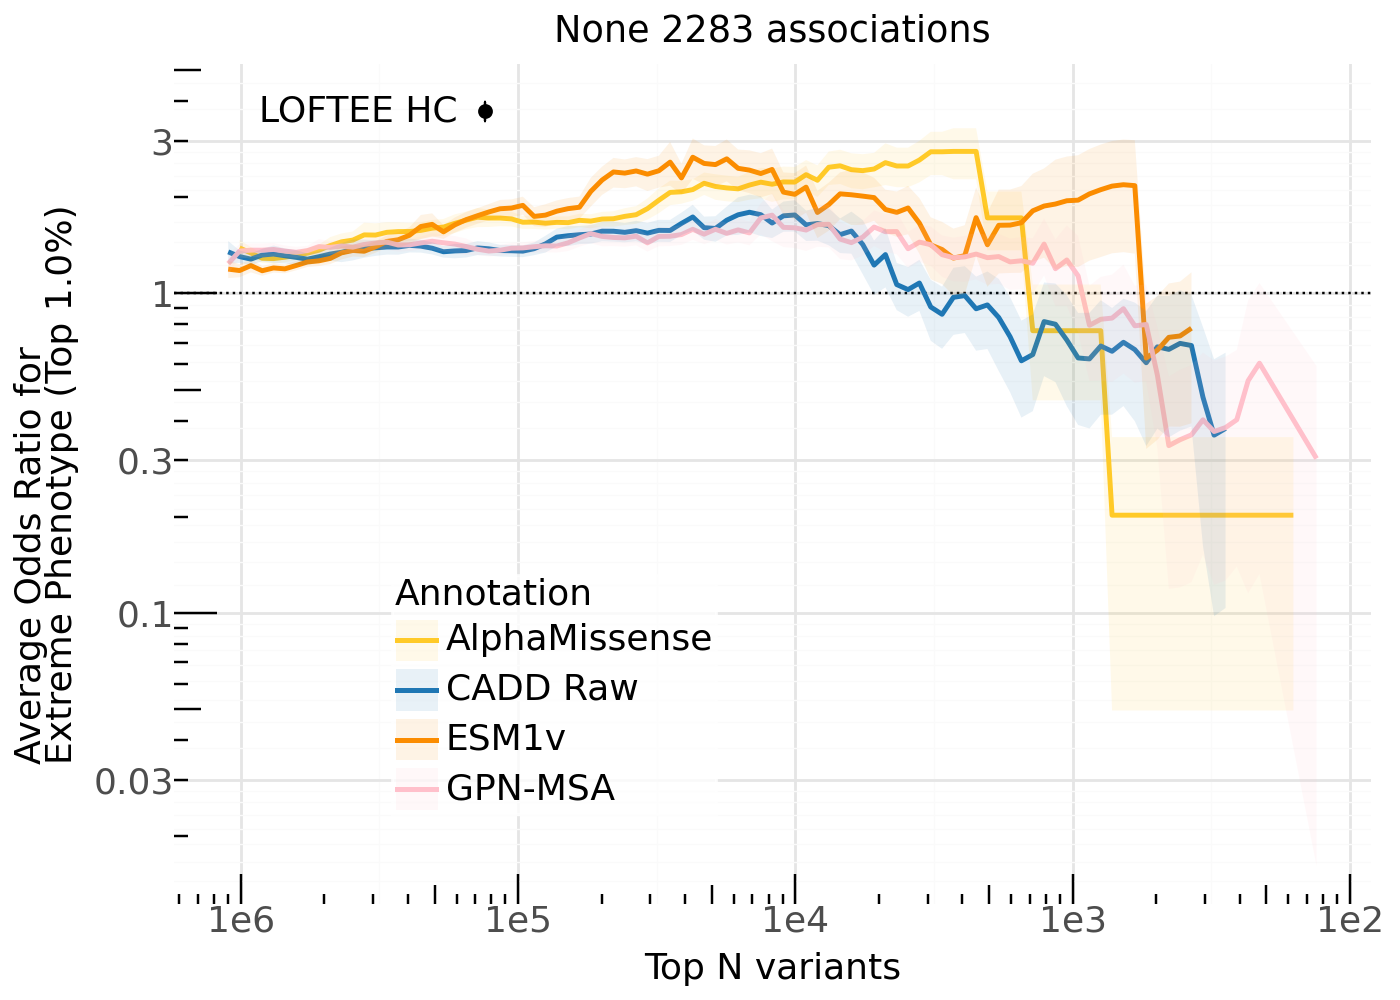

In [18]:
plot_df = (
    plt_df
    .filter(
        # (pl.col('log_rank_cutoff_inv') <= -4) &

        # (pl.col('annotation').is_in(['am_pathogenicity', 'score_pai3d', 'esmscoremissense', 'gpn_star_llr_calibrated_mean']))
        (pl.col('annotation').is_in(['am_pathogenicity', 'esmscoremissense', 'gpn_score', 'cadd_raw']))
        # (pl.col('annotation').is_in(['am_pathogenicity', 'gpn_star_llr_calibrated_mean', 'cadd_raw', 'abexp_abs_max', 'pangolin_score']))
        # (pl.col('annotation').is_in(['gpn_star_llr_calibrated_mean', 'pangolin_score', 'abexp_abs_max']))
        # (pl.col('annotation').is_in(['gpn_star_llr_calibrated_mean', 'cadd_raw', 'abexp_abs_max', 'promoterai_abs', 'max_fz_blood']))
        # (pl.col('category').is_in(['missense', 'genetic_diversity']))
    )
)

# Generate breaks and labels for x-axis
start_exp = int(np.log10(1/max_rank_cutoff))
end_exp = int(np.log10(1/min_rank_cutoff))
breaks_linear = np.arange(start_exp, end_exp + 1)
labels_sci = [f"1e{-b}" for b in breaks_linear]

color_dict = dict(zip(plt_df['label'], plt_df['color']))
pheno_label = round((1 - or_threshold_pheno) * 100, 1)

loftee_or = pl.DataFrame({
    'region': ['gene_body', 'cds'],
    'n_vars': [-np.log10(131_682), -np.log10(131_682)],
    'mean_or': [4.291864, 3.707762],
    'se_or': [0.192267, 0.130931],
}).with_columns(
    ci_low_pheno = pl.col('mean_or') - 1.96 * pl.col('se_or'),
    ci_high_pheno = pl.col('mean_or') + 1.96 * pl.col('se_or'),
)
loftee_cat = 'cds'

loftee_point  = [
    geom_point(
        loftee_or.filter(pl.col('region')==loftee_cat), 
        aes(x='n_vars', y='mean_or'),
        color='black',
        size=2
    ),
    geom_errorbar(
        loftee_or.filter(pl.col('region')==loftee_cat),
        aes(x='n_vars', y='mean_or', ymin='ci_low_pheno', ymax='ci_high_pheno'),
        width=0.01,
    ),
    geom_text(
        loftee_or.filter(pl.col('region')==loftee_cat),
        aes(x='n_vars', y='mean_or', label='"LOFTEE HC"'), # Note the double quotes for string literal
        nudge_x=-0.1,  # Adjust this to move text right/left
        size=13,      # Text size
        ha='right'     # Horizontal alignment
    )
]

(
    ggplot(
        plot_df,
        aes(x='log_rank_cutoff_inv', y='avg_odds_ratio')
    )
    + geom_hline(aes(yintercept=1), color='black', linetype='dotted')
    + geom_line(aes(color='label'), size=1)
    + geom_ribbon(aes(ymin='std_ci_lower', ymax='std_ci_upper', fill='label'), alpha=0.1)
    + loftee_point
    + scale_fill_manual(values=color_dict)
    + scale_color_manual(values=color_dict)
    + labs(
        title=f"{pheno_list_type} {or_df[['gene_name', 'phenotype']].unique().shape[0]} associations",
        y=f"Average Odds Ratio for\nExtreme Phenotype (Top {pheno_label}%)",
        x="Top N variants",
        color="Annotation",
        fill="Annotation",
    )
    + scale_x_continuous(
        breaks=breaks_linear,
        labels=labels_sci
    )
    + scale_y_log10()
    + annotation_logticks(sides="lb")
    + theme_minimal()
    + theme(
        figure_size=(7, 5),
        axis_text=element_text(size=13),
        axis_title=element_text(size=13),
        legend_text=element_text(size=13),
        legend_title=element_text(size=13),
        legend_position=(0.25, 0.15), 
        # legend_justification=(0, 0),
        legend_background=element_rect(fill="white", color='white', alpha=0.8),
        plot_background=element_rect(fill="white", color="white"),
    )
)

In [19]:
plot_df

annotation,log_rank_cutoff,rank_cutoff,log_rank_cutoff_inv,n_gene_phenos,med_odds_ratio,avg_odds_ratio,se_odds_ratio,std_ci_upper,std_ci_lower,color,label,category
str,f64,i64,f64,u64,f64,f64,f64,f64,f64,str,str,str
"""gpn_score""",2.120574,132,-2.120574,35,0.0,0.30419,0.14695,0.592212,0.016168,"""pink""","""GPN-MSA""","""conservation"""
"""am_pathogenicity""",2.20412,160,-2.20412,43,0.0,0.202222,0.077908,0.354922,0.049522,"""#FFCA28""","""AlphaMissense""","""missense"""
"""am_pathogenicity""",2.243038,175,-2.243038,43,0.0,0.202222,0.077908,0.354922,0.049522,"""#FFCA28""","""AlphaMissense""","""missense"""
"""am_pathogenicity""",2.285557,193,-2.285557,43,0.0,0.202222,0.077908,0.354922,0.049522,"""#FFCA28""","""AlphaMissense""","""missense"""
"""gpn_score""",2.326336,212,-2.326336,89,0.0,0.604544,0.240875,1.076659,0.132428,"""pink""","""GPN-MSA""","""conservation"""
…,…,…,…,…,…,…,…,…,…,…,…,…
"""gpn_score""",6.004576,1010592,-6.004576,896,1.129836,1.355423,0.03611,1.426199,1.284646,"""pink""","""GPN-MSA""","""conservation"""
"""esmscoremissense""",6.004576,1010592,-6.004576,946,1.0422,1.17849,0.028252,1.233863,1.123117,"""#FB8C00""","""ESM1v""","""missense"""
"""cadd_raw""",6.045439,1110296,-6.045439,775,1.053581,1.348142,0.055679,1.457274,1.239011,"""#1f77b4""","""CADD Raw""","""genetic_diversity"""
